In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tensorflow import keras
from data_loader import DataLoader, DataGenerator
from model_architecture import create_model

In [2]:
def train_simple_example():
    ''' 
    Simplest possible training example
    '''
    from data_loader import DataLoader
    from model_architecture import create_model

    print('='*60)
    print('Example 1: Simple Training')
    print('='*60)

    ## 1. Load data
    loader=DataLoader(image_dir='mera hissa',json_dir='mera hissa\json_files',image_sie=(416,416))

    print(f'Classes: {loader.class_names}')

    ## 2. Visualie
    print('\n Visualiing first example...')
    loader.visualie_sample(0)

    ## 3. Get data
    print('\n Loading dataset...')
    images, targets=loader.get_dataset()
    images=np.array(images)
    targets=np.array(targets)

    ## Create model
    print('\n Creating model...')
    model=create_model(num_classes=len(loader.class_names))

    ## Train
    print('\n Training...')
    history=model.fit(images, targets, epochs=10, batch_size=4, validation_split=0.2, verbose=1)

    return model, history

In [3]:
def train_with_augmentation():
    ## Training with augmentation for better generaliability

    from data_loader import DataLoader, DataGenerator
    from model_architecture import create_model

    print('\n'+'='*60)
    print('Example 2: Training with data Augmentation')
    print('\n'+'='*60)

    ## Load Data
    loader=DataLoader(image_dir='mera hissa', json_dir='mera hissa\json_files')

    images, targets=loader.get_dataset()

    ## Create generator with augmentation
    generator=DataGenerator(images, targets, batch_sie=8, augment=True)

    ## Create model
    model=create_model(num_classes=len(loader.class_names))

    ## Train using generator 
    print('Training with augmentation...')
    history=model.fit(np.array(images), np.array(targets), epochs=20, batch_size=8, validation_batch_size=0.2, shuffle=True, verbose=1)

    return model, history

In [4]:
def train_with_split():
    ## Proper train/validation/test split

    from data_loader import DataGenerator, DataLoader
    from model_architecture import create_model

    print('\n'+'='*60)
    print('Example 2: Training with data Augmentation')
    print('\n'+'='*60)

    ## Load Data
    loader=DataLoader(image_dir='mera hissa', json_dir='mera hissa\json_files')

    ## Get data
    print('\n Loading dataset...')
    images, targets=loader.get_dataset()
    images=np.array(images)
    targets=np.array(targets)

    ## Shuffle
    indices=np.random.permutation(len(images))
    images=images[indices]
    targets=targets[indices]

    ## Split
    train_sie=int(0.7*len(images))
    val_sie=int(0.15*len(images))

    x_train, x_val, x_test=(images[:train_sie], images[train_sie:train_sie+val_sie], images[train_sie+val_sie:])
    y_train, y_val, y_test=(targets[:train_sie], targets[train_sie:train_sie+val_sie], targets[train_sie+val_sie:])


    print(f' Train: {x_train.shape}')
    print(f' Val: {x_val.shape}')
    print(f' Test: {x_test.shape}')

    ## Create and train model
    model=create_model(num_classes=len(loader.class_names))

    print('\n Training...')
    history=model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=8, verbose=1)

    ## Evaluate on test data
    print('\n Evaluating on test data...')
    test_loss, test_mse=model.evaluate(x_test, y_test, verbose=1)
    print(f'Test Loss: {test_loss:.4f}')
    print(f'Test MSE: {test_mse:.4f}')

    return model, history, (x_test,y_test)

In [5]:
def demo_json_formats():
    ## show how to handle different json formats

    import json

    print('\n'+'='*60)
    print('Example 2: Training with data Augmentation')
    print('\n'+'='*60)

    ## Example 1: Polygon format
    print('\n1. Polygon Points Format:')
    json_polygon={
        'objects':[
            {
                'class':'car',
                'points':[[100,100],[200,100],[200,200],[100,200]]
            },
            {
                'class':'person',
                'points':[[300,150],[350,150],[350,300],[300,300]]
            }
        ]
    }

    print(json.dumps(json_polygon, indent=2))

    ## Example 2 : Bounding box rectangle format
    print('\n2. Bounding Box Format:')
    json_bbox={
        'objects':[
            {
                'class':'car',
                'bbox':{'x':100,'y':100,'width':100,'height':100}
            },
            {
                'class':'person',
                'bbox':{'x':300, 'y':150, 'width':50, 'height':150}                }
        ]
    }

    print(json.dumps(json_bbox, indent=2))

    ## Example 3 : Two point rectangle
    print('\n3. Two-point Rectangle Format:')
    json_2point={
        'objects':[
            {
                'class':'car',
                'points':[[100,100],[200,200]]
            }
        ]
    } 

    print(json.dumps(json_2point, indent=2))
    

    

In [6]:
def inference():
    ## Run inference on test images

    from data_loader import DataGenerator, DataLoader
    from model_architecture import predict_objects
    import cv2

    print('\n'+'='*60)
    print('Example 5: Inference on Test images')
    print('\n'+'='*60)

    ## Load model (assuming already trained)
    model=keras.models.load_model('yolo_model.h5')

    ## Loader data loader to get class names
    loader=DataLoader(image_dir='mera hissa', json_dir='mera hissa\json_files')

    ## Run inference on a test image
    image_path='mera hissa\DSC00542.JPG'

    print(f'\n Running inference on:{image_path}')
    detections=predict_objects(model, image_path, confidence_threshold=0.1)

    print(f'Found {len(detections)} objects:')

    for i, det in enumerate(detections,1):
        class_name=loader.class_names[det['class_id']]
        print(f'\n Object {i}:')
        print(f' Class: {class_name}')
        print(f" Position: {det['x_center']}_{det['y_center']}")
        print(f" Sie: {det['width']}x{det['height']}")
        print(f" Confidence: {det['objectness']}")

    return detections

In [7]:
def plot_training_history(history):
    ## Plot training history

    fig, axes=plt.subplots(1,2, figsize=(12,6))

    ## Loss
    axes[0].plot(history.history['loss'],label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss over epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    ## Lambda  Loss
    # axes[1].plot(history.history['lambda_loss'],label='Train lambda_loss')
    # axes[1].plot(history.history['val_lambda_loss'], label='Val lambda_loss')
    # axes[1].set_title('lambda_loss over epochs')
    # axes[1].set_xlabel('Epoch')
    # axes[1].set_ylabel('lambda_loss')
    # axes[1].legend()
    # axes[1].grid(True)


    ## MSE
    # axes[1].plot(history.history['mse'],label='Train MSE')
    # axes[1].plot(history.history['val_mse'], label='Val MSE')
    # axes[1].set_title('MSE over epochs')
    # axes[1].set_xlabel('Epoch')
    # axes[1].set_ylabel('MSE')
    # axes[1].legend()
    # axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
def print_class_distribution(loader):
    ## Print class distribution statistics

    from data_loader import DataLoader

    print('\n'+'='*60)
    print('Class distribution analysis')
    print('\n'+'='*60)

    class_counts={class_name: 0 for class_name in loader.class_names}
    image_count=0

    for image_file in loader.image_files:
        annotations=loader.load_annotations(image_file)
        if annotations:
            image_count=image_count+1
            for ann in annotations:
                class_id=ann['class_id']
                class_name=loader.class_names[class_id]
                class_counts[class_name]+=1


    print(f'Total images with objects: {image_count}')
    print(f'Total objects: {sum(class_counts.values())}\n')

    for class_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
        percentage=(count/sum(class_counts.values())*100) if sum(class_counts.values())>0 else 0
        print(f' {class_name:20s}:{count:5d} ({percentage:5.1f}%)')
        


In [9]:
def main():
    ## Main training pipeline

    print('\n'+'='*60)
    print('Class distribution analysis')
    print('\n'+'='*60)

    ## Configuration
    config={
        'image_dir':'mera hissa', 'json_dir':'mera hissa\json_files', 'epochs':50, 'batch_sie':16, 'learning_rate':1.0
    }

    ## Step 1 Load data
    print('\n [1/6] Loading data...')
    from data_loader import DataLoader
    import numpy as np

    loader=DataLoader(image_dir=config['image_dir'], json_dir=config['json_dir'], image_sie=(416,416))

    print(f' Found {len(loader.image_files)} images')
    print(f' Classes: {loader.class_names}')

    '''## Step 2: Visualiin samples
    print('\n [2/6] Visualising samples...')
    loader.visualie_batch(num_samples=5)

    ## Step 3: Print statistics
    print('\n [3/6] Class distribution:')
    print_class_distribution(loader)'''

    ## Step 4: Load full dataset
    print('\n [4/6] Loading full dataset...')
    images, targets=loader.get_dataset()
    images=np.array(images)

    ## IMPORTANT: `targets` is a list of per-image samples, and EACH sample
    ## is itself a list of 3 arrays [target_fine, target_medium, target_coarse]
    ## - one per detection scale - and these 3 arrays have DIFFERENT shapes
    ## (different grid sizes). So np.array(targets) can't stack them into one
    ## array -> "inhomogeneous shape" error. Split by scale first instead,
    ## since model.fit() expects a list of 3 target arrays (one per output head):
    targets_fine=np.array([t[0] for t in targets])
    targets_medium=np.array([t[1] for t in targets])
    targets_coarse=np.array([t[2] for t in targets])
    targets=[targets_fine, targets_medium, targets_coarse]

    print(f' Images shape: {images.shape}')
    print(f' Targets shapes (fine, medium, coarse): {[t.shape for t in targets]}')

    ## Step 5: Create model
    print('\n[5/6] Creating model...')
    from model_architecture import create_model

    model=create_model(num_classes=len(loader.class_names))
    print(' Model created sucessfully')
    from tensorflow.keras .callbacks import EarlyStopping,ReduceLROnPlateau
    reduce_lr=ReduceLROnPlateau(monitor='loss',factor=0.5,patience=10,min_lr=0.00001)
    early_stopping=EarlyStopping(monitor='val_loss',patience=100,restore_best_weights=True)

    import os
    import tensorflow as tf

    os.makedirs("checkpoints", exist_ok=True)

    class SaveEvery100Epochs(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % 100 == 0:
                path = f"checkpoints/model_epoch_{epoch + 1}.keras"
                self.model.save(path)
                print(f"\nModel saved at epoch {epoch + 1}")


    ## Step 6: Train
    print('\n[6/6] Training...')
    history=model.fit(images, targets, epochs=config['epochs'], batch_size=config['batch_sie'], validation_split=0.2, shuffle=True,verbose=1, callbacks=[SaveEvery100Epochs()])

    ## Save model
    print('\n Saving model...')
    model.save('yolo_model.h5') 
    print('Model saved to "yoloy_model.h5"')       

    ## Plot results
    print('\n Plotting results...')
    plot_training_history(history)

    return model, loader,history


Class distribution analysis


 [1/6] Loading data...
Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']
 Found 398 images
 Classes: ['raw', 'ripe']

 [4/6] Loading full dataset...
Loading 10/398
Loading 20/398
Loading 30/398
Loading 40/398
Loading 50/398
Loading 60/398
Loading 70/398
Loading 80/398
Loading 90/398
Loading 100/398
Loading 110/398
Loading 120/398
Loading 130/398
Loading 140/398
Loading 150/398
Loading 160/398
Loading 170/398
Loading 180/398
Loading 190/398
Loading 200/398
Loading 210/398
Loading 220/398
Loading 230/398
Loading 240/398
Loading 250/398
Loading 260/398
Loading 270/398
Loading 280/398
Loading 290/398
Loading 300/398
Loading 310/398
Loading 320/398
Loading 330/398
Loading 340/398
Loading 350/398
Loading 360/398
Loading 370/398
Loading 380/398
Loading 390/398
 Images shape: (398, 416, 416, 3)
 Targets shapes (fine, medium, coarse): [(398, 52, 52, 1, 7), (398, 26, 26, 1, 7), (398, 13, 13, 1, 7)]

[5/6] Creating model...
 Model created sucessfull


 Saving model...
Model saved to "yoloy_model.h5"

 Plotting results...


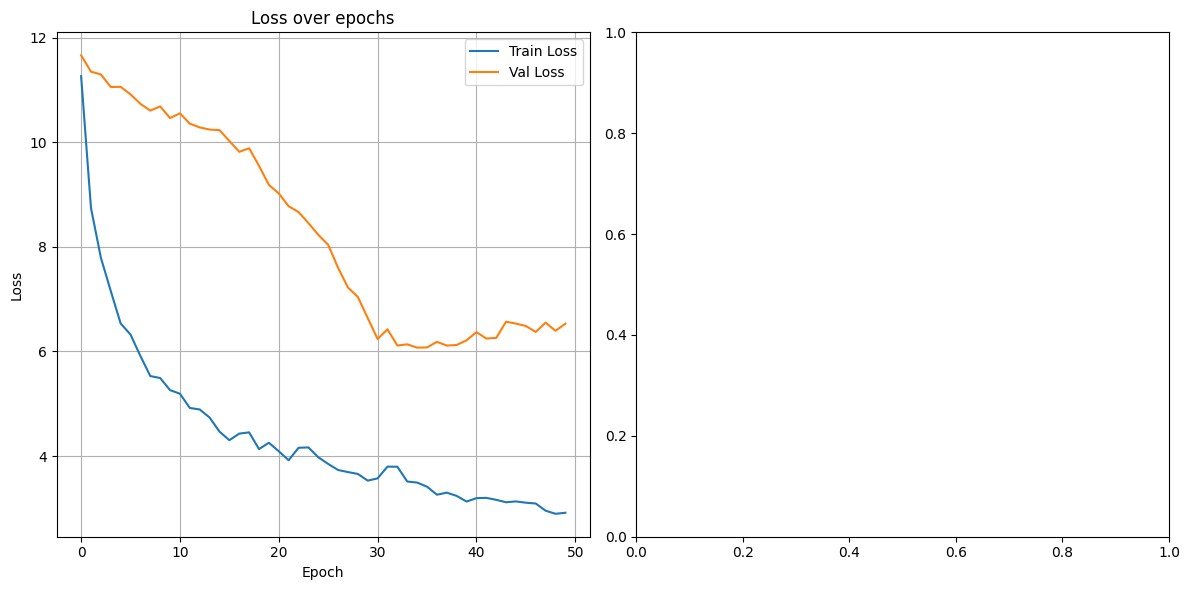


Training complete



In [10]:
if __name__=='__main__':
    ## Choose which example to run:

    ## Option 1 simple training
    #model, history=train_simple_example()

    ## Option 2 with augmentation
    #model, history=train_with_augmentation()

    ## Option 3 with proper split
    #+model, history, test_data=train_with_split()
    ## Option 4 See JSON format
    #demo_json_formats()


    ## Option 5 Run inference
    #detections=inference()

    ## Option 6: Full pipeline
    model, loader ,history=main()

    print('\n'+'='*60)
    print('Training complete')
    print('\n'+'='*60)



 Plotting results...


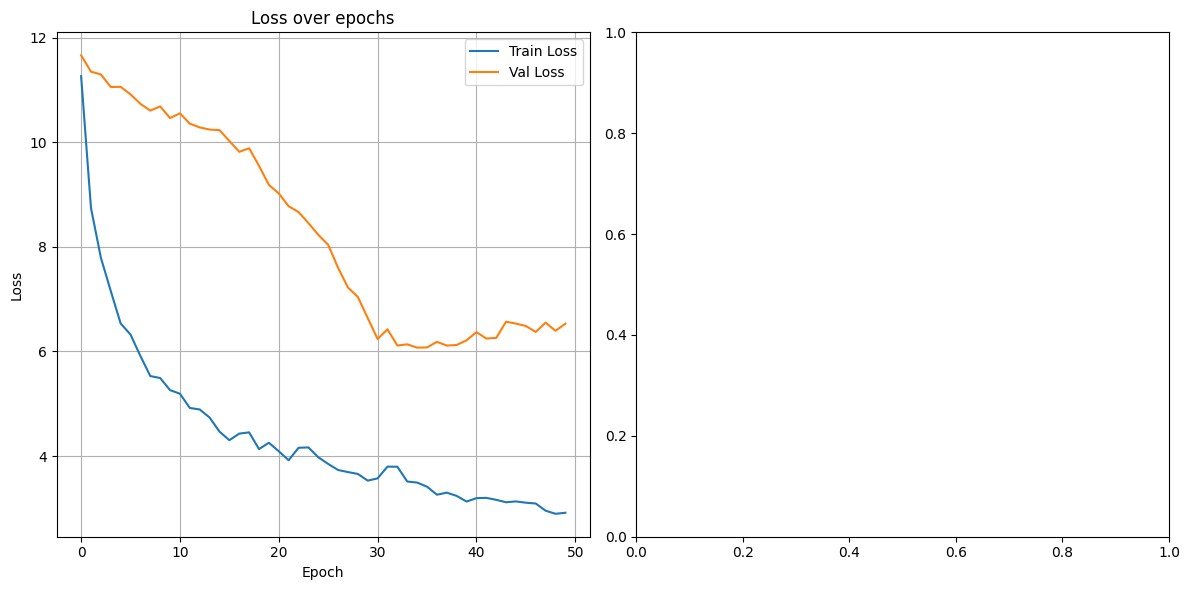

In [11]:
print('\n Plotting results...')
plot_training_history(history)


In [12]:
model.save('model.h5')

In [13]:
import tensorflow as tf
from tensorflow import keras
from model_architecture import Lightweight

model = keras.models.load_model(
    "model.h5",
    custom_objects={"Lightweight": Lightweight},
    compile=False,
)

# Build the model once by calling it, so it has a concrete input shape
# (needed since it's a subclassed model, not Functional/Sequential)
dummy = tf.zeros((1, 416, 416, 3), dtype=tf.float32)
_ = model(dummy, training=False)

# Export to SavedModel format (Keras 3 way — TF 2.16+)
model.export("saved_model_dir")

# Convert from the SavedModel, not from the Keras object directly
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model_dir")
# converter.optimizations = [tf.lite.Optimize.DEFAULT]  # optional
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved model.tflite:", len(tflite_model), "bytes")

INFO:tensorflow:Assets written to: saved_model_dir\assets


INFO:tensorflow:Assets written to: saved_model_dir\assets


Saved artifact at 'saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 416, 416, 3), dtype=tf.float32, name=None)
Output Type:
  List[TensorSpec(shape=(None, 52, 52, 1, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None, 26, 26, 1, 7), dtype=tf.float32, name=None), TensorSpec(shape=(None, 13, 13, 1, 7), dtype=tf.float32, name=None)]
Captures:
  2901510191968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774158832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774161472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774158480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774159888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774167104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774163232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774169216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2901774166224: TensorSpec(

In [14]:
'''import cv2
def inference(model,image_path):
    ## Run inference on test images

    from yolo_data_loader import DataGenerator, DataLoader
    from YOLO_5_OLD import predict_objects
    import cv2


    ## Load model (assuming already trained)
    #model=keras.models.load_model('yolo_model.h5')

    ## Loader data loader to get class names
    loader=DataLoader(image_dir='mera hissa', json_dir='mera hissa\json_files')

   

    print(f'\n Running inference on:{image_path}')
    print('HI')
    detections=predict_objects(model, image_path, confidence_threshold=0.0)
    print('hELLO')
    print(detections)
    print(f'Found {len(detections)} objects:')

    for i, det in enumerate(detections,1):
        class_name=loader.class_names[det['class_id']]
        print(f'\n Object {i}:')
        print(f' Class: {class_name}')
        #print(f' Position: {det['x_center']}x {det['y_center']}')
        #print(f' Sie:'+{det['width']}+'x'+{det['height']})
        #print(f' Confidence:' +{det['objectness']})

    return detections

if __name__=='__main__':
    ## Choose which example to run:

    ## Option 1 simple training
    #model, history=train_simple_example()

    ## Option 2 with augmentation
    #model, history=train_with_augmentation()

    ## Option 3 with proper split
    #model, history, test_data=train_with_split()

    ## Option 4 See JSON formats
    #demo_json_formats()

    ## Option 5 Run inference
    
    #model=keras.models.load_model('yolo_model.h5')
    ## Run inference on a test image
    image_path='mera hissa\DSC00937.JPG'

    detections=inference(model,image_path)
    print(detections)

    ## Option 6: Full pipeline
    #model, loader ,history=main()

    print('\n'+'='*60)
    print('Training complete')
    print('\n'+'='*60)
    
    out_path='out1.jpg'

    img=cv2.imread(image_path)
    H,W=img.shape[:2]
    for i in detections:
        print(i)
        xc,yc,w,h=i['x_center'],i['y_center'],i['width'],i['height']
        xc,yc,w,h=xc*W,yc*H, w*W, h*H
        print(xc)

        x1,y1=int(xc-w/2),int(yc-h/2)
        x2,y2=int(xc+w/2), int(yc+h/2)
        print(x1)
        print(x2)
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    cv2.imwrite(out_path, img)

    out_path='out1.jpg'

    img=cv2.imread(image_path)
    H,W=img.shape[:2]
    for i in detections:
        print(i)
        xc,yc,w,h=i['x_center'],i['y_center'],i['width'],i['height']
        xc,yc,w,h=xc*W,yc*H, w*W, h*H
        print(xc)

        x1,y1=int(xc-w/2),int(yc-h/2)
        x2,y2=int(xc+w/2), int(yc+h/2)
        print(x1)
        print(x2)
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    cv2.imwrite(out_path, img)
'''

"import cv2\ndef inference(model,image_path):\n    ## Run inference on test images\n\n    from yolo_data_loader import DataGenerator, DataLoader\n    from YOLO_5_OLD import predict_objects\n    import cv2\n\n\n    ## Load model (assuming already trained)\n    #model=keras.models.load_model('yolo_model.h5')\n\n    ## Loader data loader to get class names\n    loader=DataLoader(image_dir='mera hissa', json_dir='mera hissa\\json_files')\n\n   \n\n    print(f'\n Running inference on:{image_path}')\n    print('HI')\n    detections=predict_objects(model, image_path, confidence_threshold=0.0)\n    print('hELLO')\n    print(detections)\n    print(f'Found {len(detections)} objects:')\n\n    for i, det in enumerate(detections,1):\n        class_name=loader.class_names[det['class_id']]\n        print(f'\n Object {i}:')\n        print(f' Class: {class_name}')\n        #print(f' Position: {det['x_center']}x {det['y_center']}')\n        #print(f' Sie:'+{det['width']}+'x'+{det['height']})\n        #p

In [15]:
'''import cv2
def draw_bbox(img_path, xc,yc, w,h, out_path='out.jpg',norm=True):
    img=cv2.imread(img_path)
    H,W=img.shape[:2]

    if norm:
        xc,yc,w,h-xc*W,yc*H, w*W, h*H

    x1,y1=int(xc-w/2),int(yc-h/2)
    x2,y2=int(xc+w/2), int(yc+h/2)

    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    cv2.imwrite(out_path, img)
    '''

"import cv2\ndef draw_bbox(img_path, xc,yc, w,h, out_path='out.jpg',norm=True):\n    img=cv2.imread(img_path)\n    H,W=img.shape[:2]\n\n    if norm:\n        xc,yc,w,h-xc*W,yc*H, w*W, h*H\n\n    x1,y1=int(xc-w/2),int(yc-h/2)\n    x2,y2=int(xc+w/2), int(yc+h/2)\n\n    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)\n    cv2.imwrite(out_path, img)\n    "

In [16]:
'''for i in detections:
    print(i['x_center'])
    print(i['y_center'])
    print(i['width'])
    print(i['height'])'''

"for i in detections:\n    print(i['x_center'])\n    print(i['y_center'])\n    print(i['width'])\n    print(i['height'])"

In [17]:
# detections,i['width'],i['width'],i['width']

In [18]:
# from tensorflow.keras.models import load_model

# model = load_model("yoloy_model.h5")

Found 398 images:


Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 6 objects


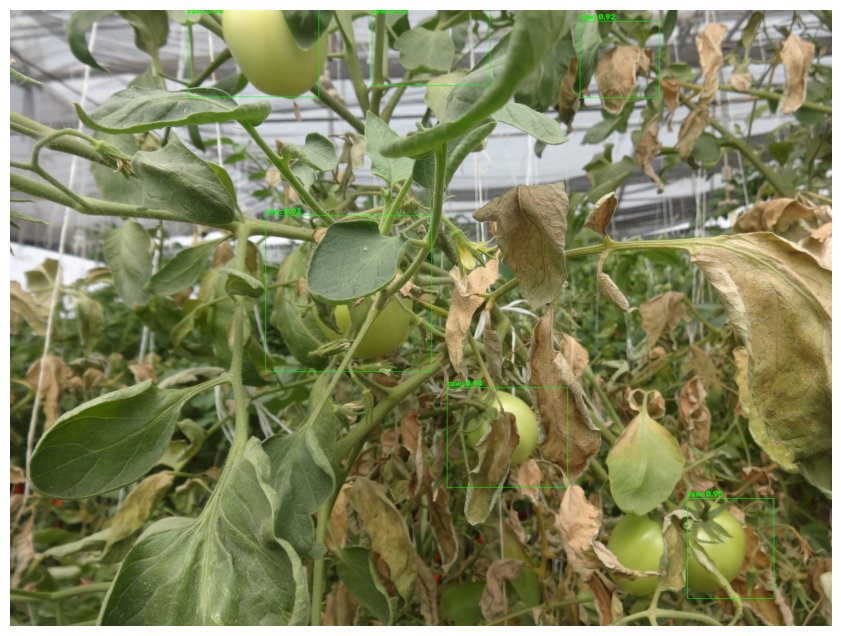

In [19]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00558.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.86,
    iou_threshold=0.05
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 7 objects


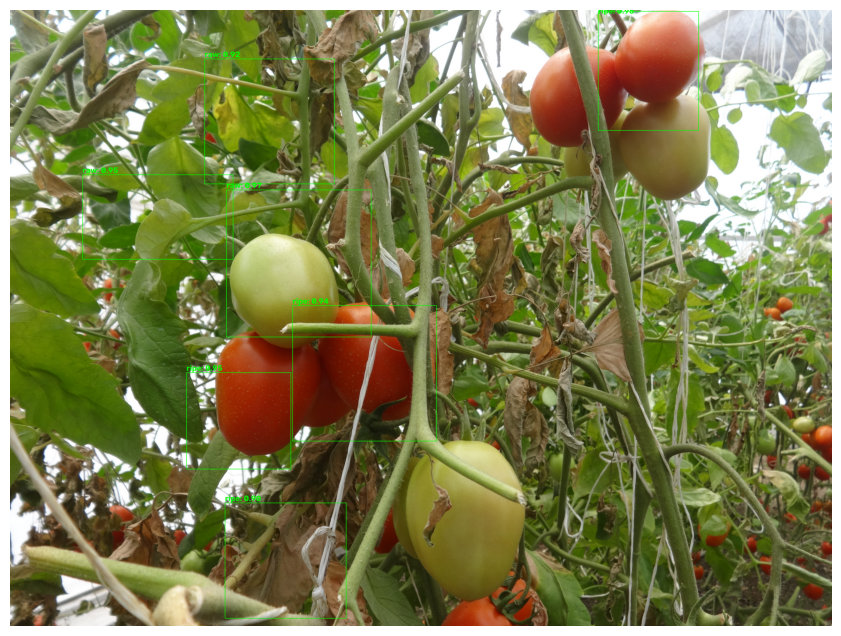

In [20]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00981.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.89,
    iou_threshold=0.05
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 9 objects


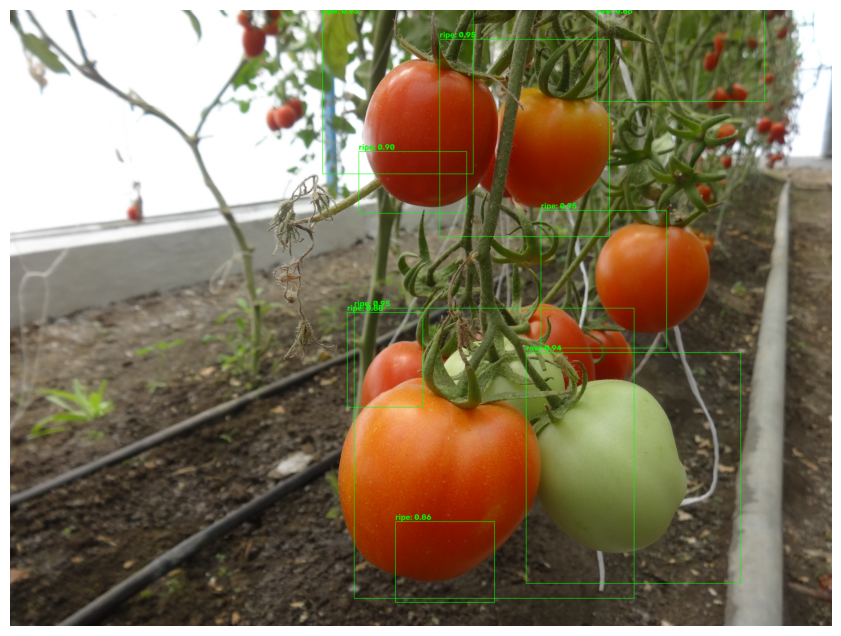

In [21]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00958.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.8,
    iou_threshold=0.1
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 7 objects


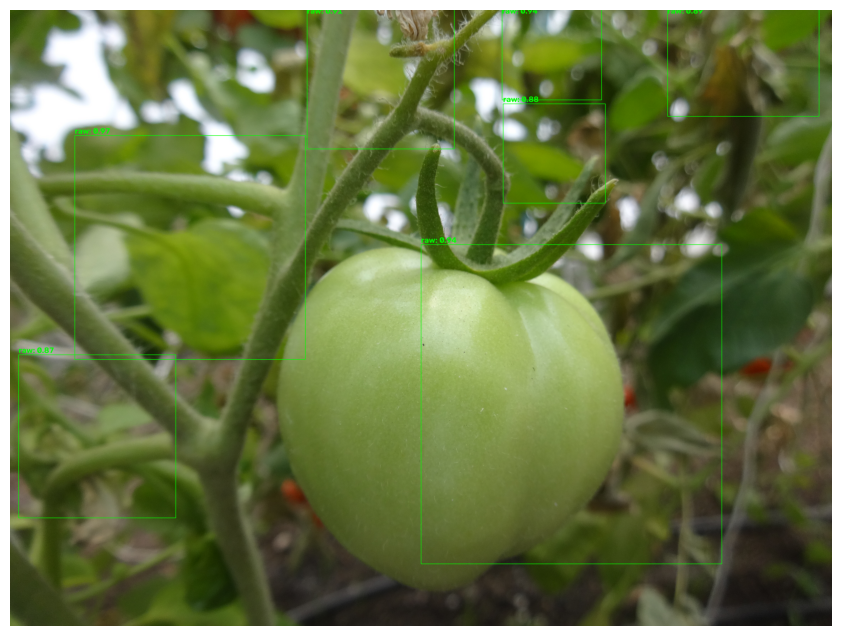

In [22]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00986.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.80,
    iou_threshold=0.01
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 33 objects


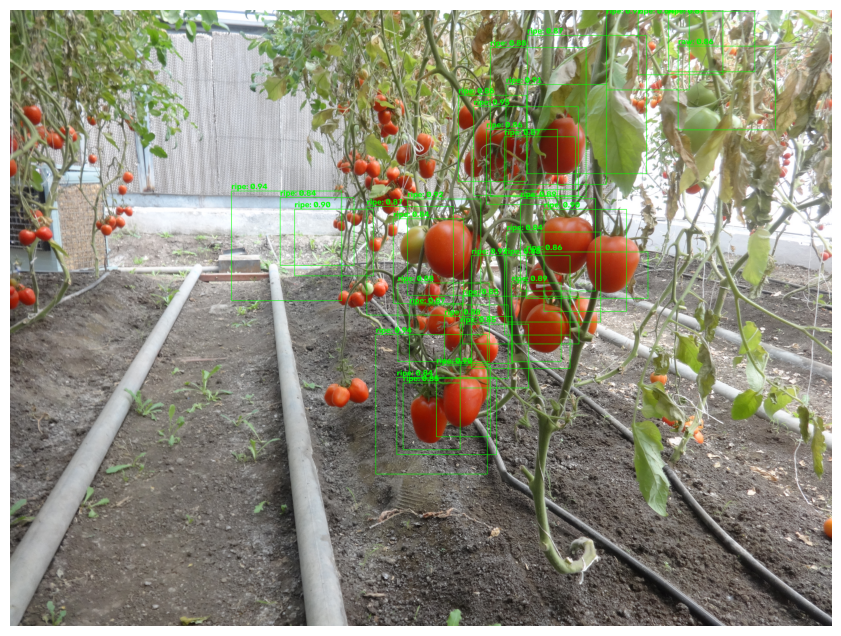

In [23]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00931.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.8,
    iou_threshold=0.5
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 51 objects


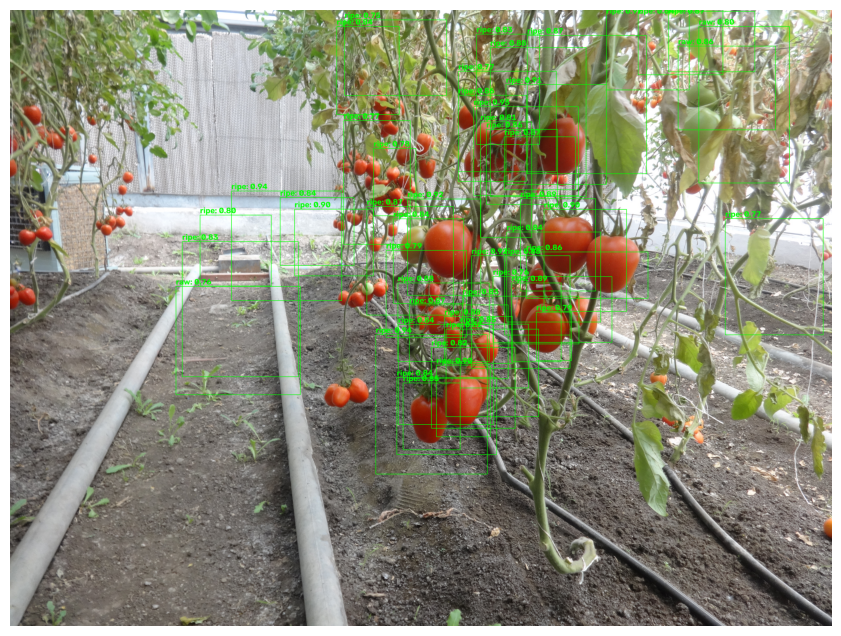

In [24]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00931.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.73
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']

Detected 100 objects


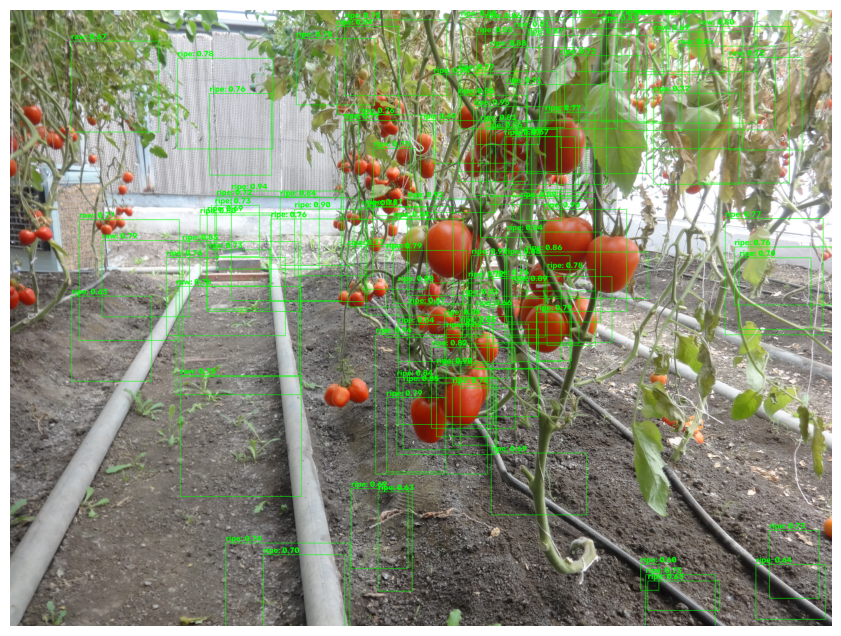

In [25]:
import cv2
import matplotlib.pyplot as plt
from model_architecture import predict_objects
from data_loader import DataLoader

# Path to your NEW image
image_path = r"mera hissa\DSC00931.jpg"

# Get class names
loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)

# Run prediction
detections = predict_objects(
    model,
    image_path,
    confidence_threshold=0.6
    

)

print(f"\nDetected {len(detections)} objects")

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

# Draw detections
for det in detections:

    # Convert normalized coordinates to pixels
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]
    confidence = det["objectness"]

    # Draw box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Draw label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [26]:
from tensorflow.keras.models import load_model

model = load_model(r"checkpoints/model_epoch_100.keras", compile=False)

TypeError: Could not locate class 'LightweightYOLO'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'claude_3', 'class_name': 'LightweightYOLO', 'config': {'name': 'lightweight_yolo_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'num_classes': 2, 'num_anchors': 1, 'input_shape': [416, 416, 3], 'anchors': {'fine': [[0.10000000149011612, 0.12999999523162842]], 'medium': [[0.2800000011920929, 0.3499999940395355]], 'coarse': [[0.5799999833106995, 0.6399999856948853]]}}, 'registered_name': 'TomatoYOLO>LightweightYOLO', 'build_config': {'input_shape': [1, 416, 416, 3]}, 'compile_config': None}

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from model_architecture import predict_objects
from data_loader import DataLoader


# ==============================
# SETTINGS
# ==============================

image_path = r"mera hissa\DSC00981.jpg"

confidence_threshold = 0.8
iou_threshold = 0.1


# ==============================
# LOAD CLASS NAMES
# ==============================

loader = DataLoader(
    image_dir="mera hissa",
    json_dir=r"mera hissa\json_files"
)


# ==============================
# PREDICTION
# ==============================

detections = predict_objects(
    model,
    image_path,
    confidence_threshold=confidence_threshold
)

print(f"Before NMS: {len(detections)} objects")


# ==============================
# NMS
# ==============================

def apply_nms(detections, iou_threshold=0.5):

    if not detections:
        return []

    boxes = []
    scores = []

    for det in detections:

        x_center = det["x_center"]
        y_center = det["y_center"]
        width = det["width"]
        height = det["height"]

        x1 = x_center - width / 2
        y1 = y_center - height / 2
        x2 = x_center + width / 2
        y2 = y_center + height / 2

        boxes.append([x1, y1, x2, y2])
        scores.append(det["objectness"])

    boxes = np.array(boxes)
    scores = np.array(scores)

    keep = []

    # NMS separately for each class
    class_ids = set(det["class_id"] for det in detections)

    for class_id in class_ids:

        class_indices = [
            i for i, det in enumerate(detections)
            if det["class_id"] == class_id
        ]

        # Highest confidence first
        class_indices.sort(
            key=lambda i: scores[i],
            reverse=True
        )

        while class_indices:

            best = class_indices.pop(0)
            keep.append(best)

            remaining = []

            for idx in class_indices:

                # Intersection
                x1 = max(boxes[best][0], boxes[idx][0])
                y1 = max(boxes[best][1], boxes[idx][1])
                x2 = min(boxes[best][2], boxes[idx][2])
                y2 = min(boxes[best][3], boxes[idx][3])

                intersection = (
                    max(0, x2 - x1) *
                    max(0, y2 - y1)
                )

                # Areas
                area_best = (
                    (boxes[best][2] - boxes[best][0]) *
                    (boxes[best][3] - boxes[best][1])
                )

                area_idx = (
                    (boxes[idx][2] - boxes[idx][0]) *
                    (boxes[idx][3] - boxes[idx][1])
                )

                union = area_best + area_idx - intersection

                iou = intersection / union if union > 0 else 0

                # Keep if IoU is below threshold
                if iou < iou_threshold:
                    remaining.append(idx)

            class_indices = remaining

    return [detections[i] for i in keep]


# Apply NMS
detections = apply_nms(
    detections,
    iou_threshold=iou_threshold
)

print(f"After NMS: {len(detections)} objects")


# ==============================
# LOAD IMAGE
# ==============================

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]


# ==============================
# DRAW DETECTIONS
# ==============================

for det in detections:

    # Normalized → pixel coordinates
    x_center = det["x_center"] * width
    y_center = det["y_center"] * height
    box_width = det["width"] * width
    box_height = det["height"] * height

    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    class_id = det["class_id"]
    class_name = loader.class_names[class_id]

    confidence = det["objectness"]

    # Bounding box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    # Label
    label = f"{class_name}: {confidence:.2f}"

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (0, 255, 0),
        2
    )


# ==============================
# SHOW IMAGE
# ==============================

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

Found 398 images:
Auto-detected 2 classes
Classes: ['raw', 'ripe']


NameError: name 'model' is not defined